In [1]:
from __future__ import annotations

import json
import math
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import rowcol
from rasterio.warp import Resampling, reproject

try:
    from scipy import ndimage
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False


NODATA_VALUE = -9999.0
ATTR_MIN = 1e-6
EPS = 1e-6
BETA = 2.0
LOG_EVERY = 2000

# 8-neighborhood moves, distance factor in pixel units.
NEIGHBORS = (
    (-1, 0, 1.0),
    (1, 0, 1.0),
    (0, -1, 1.0),
    (0, 1, 1.0),
    (-1, -1, math.sqrt(2.0)),
    (-1, 1, math.sqrt(2.0)),
    (1, -1, math.sqrt(2.0)),
    (1, 1, math.sqrt(2.0)),
)


@dataclass
class ResellerSeed:
    reseller_id: float
    attractiveness: float
    row: int
    col: int


@dataclass
class DijkstraResult:
    best_seed_idx: np.ndarray
    best_time_min: np.ndarray
    assigned_targets: int
    elapsed_sec: float


def _now() -> float:
    return time.perf_counter()


def _safe_ratio(n: float, d: float) -> float:
    return float(n / d) if d else 0.0


def _print_progress(prefix: str, assigned: int, total: int, elapsed: float) -> None:
    if total <= 0:
        return
    pct = 100.0 * assigned / total
    rate = _safe_ratio(assigned, elapsed)
    remaining = max(total - assigned, 0)
    eta_sec = _safe_ratio(remaining, max(rate, 1e-12))
    print(
        f"[{prefix}] {assigned}/{total} ({pct:.2f}%) | "
        f"{rate:.1f} px/s | ETA {eta_sec/60.0:.1f} min"
    )


def read_reference_population(pop_path: Path) -> Tuple[np.ndarray, Dict]:
    with rasterio.open(pop_path) as src:
        pop = src.read(1).astype(np.float32)
        profile = src.profile.copy()
    return pop, profile


def reproject_match_reference(
    src_path: Path,
    ref_profile: Dict,
    resampling: Resampling,
) -> np.ndarray:
    dst = np.full(
        (ref_profile["height"], ref_profile["width"]),
        np.nan,
        dtype=np.float32,
    )
    with rasterio.open(src_path) as src:
        reproject(
            source=rasterio.band(src, 1),
            destination=dst,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src.nodata,
            dst_transform=ref_profile["transform"],
            dst_crs=ref_profile["crs"],
            dst_nodata=np.nan,
            resampling=resampling,
        )
    return dst


def normalize_car_share(car_share: np.ndarray) -> np.ndarray:
    arr = car_share.astype(np.float32, copy=True)
    finite = np.isfinite(arr)
    if finite.any():
        vmax = float(np.nanmax(arr[finite]))
        if vmax > 1.0 + 1e-4 and vmax <= 100.0 + 1e-4:
            arr[finite] = arr[finite] / 100.0
    arr[~finite] = 0.0
    np.clip(arr, 0.0, 1.0, out=arr)
    return arr


def sanitize_friction(arr: np.ndarray) -> np.ndarray:
    out = arr.astype(np.float32, copy=True)
    invalid = ~np.isfinite(out) | (out <= 0.0)
    out[invalid] = np.nan
    return out


def connected_components_8(mask: np.ndarray) -> np.ndarray:
    """Return labels (0 = background) for 8-connected True cells."""
    if HAS_SCIPY:
        structure = np.ones((3, 3), dtype=np.uint8)
        labels, _ = ndimage.label(mask, structure=structure)
        return labels.astype(np.int32)

    h, w = mask.shape
    labels = np.zeros((h, w), dtype=np.int32)
    current = 0
    stack: List[Tuple[int, int]] = []
    for r in range(h):
        for c in range(w):
            if not mask[r, c] or labels[r, c] != 0:
                continue
            current += 1
            labels[r, c] = current
            stack.append((r, c))
            while stack:
                rr, cc = stack.pop()
                for dr, dc, _ in NEIGHBORS:
                    nr, nc = rr + dr, cc + dc
                    if nr < 0 or nr >= h or nc < 0 or nc >= w:
                        continue
                    if not mask[nr, nc] or labels[nr, nc] != 0:
                        continue
                    labels[nr, nc] = current
                    stack.append((nr, nc))
    return labels


def load_reseller_seeds(
    gpkg_path: Path,
    layer: str,
    id_col: str,
    attractiveness_col: str,
    ref_profile: Dict,
) -> List[ResellerSeed]:
    gdf = gpd.read_file(gpkg_path, layer=layer)
    if gdf.empty:
        raise ValueError("No reseller features found in the input layer.")

    ref_crs = ref_profile["crs"]
    if gdf.crs is None:
        raise ValueError("Input GeoPackage has no CRS.")
    if gdf.crs != ref_crs:
        gdf = gdf.to_crs(ref_crs)

    ids = pd.to_numeric(gdf[id_col], errors="coerce")
    attrs = pd.to_numeric(gdf[attractiveness_col], errors="coerce")
    attrs = attrs.fillna(ATTR_MIN).clip(lower=ATTR_MIN)

    xs = gdf.geometry.x.to_numpy()
    ys = gdf.geometry.y.to_numpy()
    rows, cols = rowcol(ref_profile["transform"], xs, ys)

    h = int(ref_profile["height"])
    w = int(ref_profile["width"])

    # Keep only valid numeric IDs and in-grid points.
    tmp: Dict[Tuple[int, int], ResellerSeed] = {}
    for rid, att, r, c in zip(ids.to_numpy(), attrs.to_numpy(), rows, cols):
        if not np.isfinite(rid):
            continue
        rr = int(r)
        cc = int(c)
        if rr < 0 or rr >= h or cc < 0 or cc >= w:
            continue

        key = (rr, cc)
        candidate = ResellerSeed(
            reseller_id=float(rid),
            attractiveness=float(att),
            row=rr,
            col=cc,
        )

        # If multiple points map to same pixel, keep the most attractive one.
        prev = tmp.get(key)
        if prev is None or candidate.attractiveness > prev.attractiveness:
            tmp[key] = candidate

    seeds = list(tmp.values())
    if not seeds:
        raise ValueError("No valid reseller seeds mapped on reference grid.")
    return seeds


def _run_component_retry(
    best_adj: np.ndarray,
    best_time: np.ndarray,
    best_seed: np.ndarray,
    traversable: np.ndarray,
    friction: np.ndarray,
    comp_mask: np.ndarray,
    comp_targets: np.ndarray,
    comp_seed_idx: np.ndarray,
    seed_rows: np.ndarray,
    seed_cols: np.ndarray,
    sqrt_attr: np.ndarray,
    pixel_size_m: float,
) -> None:
    import heapq

    h, w = friction.shape
    done = np.zeros((h, w), dtype=bool)

    heap: List[Tuple[float, int, int, int]] = []
    for si in comp_seed_idx.tolist():
        r0 = int(seed_rows[si])
        c0 = int(seed_cols[si])
        if not comp_mask[r0, c0] or not traversable[r0, c0]:
            continue

        if best_adj[r0, c0] > 0.0 or best_seed[r0, c0] < 0:
            best_adj[r0, c0] = 0.0
            best_time[r0, c0] = 0.0
            best_seed[r0, c0] = si

        heapq.heappush(heap, (best_adj[r0, c0], r0, c0, si))

    remaining = int(np.count_nonzero(comp_targets & (best_seed < 0)))

    while heap and remaining > 0:
        adj, r, c, si = heapq.heappop(heap)
        if done[r, c]:
            continue
        if adj > best_adj[r, c]:
            continue
        if not comp_mask[r, c]:
            continue

        done[r, c] = True

        if comp_targets[r, c] and best_seed[r, c] >= 0:
            remaining -= 1

        inv_scale = 1.0 / sqrt_attr[si]
        t_curr = best_time[r, c]

        for dr, dc, dist_factor in NEIGHBORS:
            nr = r + dr
            nc = c + dc
            if nr < 0 or nr >= h or nc < 0 or nc >= w:
                continue
            if done[nr, nc] or not traversable[nr, nc] or not comp_mask[nr, nc]:
                continue
            #modified in respect to 4.y
            edge_time = 0.5 * (float(friction_min_per_m[r, c]) + float(friction_min_per_m[nr, nc])) * (pixel_size_m * dist_factor)
            t_new = t_curr + edge_time
            adj_new = t_new * inv_scale

            if (adj_new + 1e-12) < best_adj[nr, nc] or (
                abs(adj_new - best_adj[nr, nc]) <= 1e-12 and t_new < best_time[nr, nc]
            ):
                best_adj[nr, nc] = adj_new
                best_time[nr, nc] = t_new
                best_seed[nr, nc] = si
                heapq.heappush(heap, (adj_new, nr, nc, si))


def run_huff_multisource_dijkstra(
    mode_name: str,
    friction_min_per_m: np.ndarray,
    traversable_mask: np.ndarray,
    target_mask: np.ndarray,
    labels: np.ndarray,
    seeds: Sequence[ResellerSeed],
    pixel_size_m: float,
    log_every: int = LOG_EVERY,
) -> Tuple[DijkstraResult, int]:
    """Single-pass optimized Huff assignment using source-weighted multi-source Dijkstra.

    Objective: maximize A / (t + EPS)^BETA, with BETA=2.
    Equivalent minimization for each source s: t / A^(1/BETA).
    """
    import heapq

    h, w = friction_min_per_m.shape

    best_adj = np.full((h, w), np.inf, dtype=np.float64)
    best_time = np.full((h, w), np.inf, dtype=np.float64)
    best_seed = np.full((h, w), -1, dtype=np.int32)
    finalized = np.zeros((h, w), dtype=bool)

    sqrt_attr = np.array([math.sqrt(max(s.attractiveness, ATTR_MIN)) for s in seeds], dtype=np.float64)
    seed_rows = np.array([s.row for s in seeds], dtype=np.int32)
    seed_cols = np.array([s.col for s in seeds], dtype=np.int32)

    # Identify labels with at least one seed. Fallback targets only these components.
    seed_labels = labels[seed_rows, seed_cols]
    max_label = int(labels.max())
    has_seed = np.zeros(max_label + 1, dtype=bool)
    has_seed[seed_labels[seed_labels > 0]] = True

    heap: List[Tuple[float, int, int, int]] = []
    for si, (r, c) in enumerate(zip(seed_rows, seed_cols)):
        if not traversable_mask[r, c]:
            continue
        prev_adj = best_adj[r, c]
        # Tie-break at source pixel: higher attractiveness preferred.
        if (0.0 < prev_adj) or (
            prev_adj == 0.0 and best_seed[r, c] >= 0 and sqrt_attr[si] > sqrt_attr[best_seed[r, c]]
        ):
            best_adj[r, c] = 0.0
            best_time[r, c] = 0.0
            best_seed[r, c] = si
            heapq.heappush(heap, (0.0, r, c, si))

    target_count = int(np.count_nonzero(target_mask & traversable_mask))
    assigned = 0
    fallback_hits = 0
    t0 = _now()
    last_log = 0

    while heap and assigned < target_count:
        adj, r, c, si = heapq.heappop(heap)
        if finalized[r, c]:
            continue
        if adj > best_adj[r, c]:
            continue

        finalized[r, c] = True

        if target_mask[r, c]:
            assigned += 1
            if assigned - last_log >= log_every:
                _print_progress(mode_name, assigned, target_count, _now() - t0)
                last_log = assigned

        inv_scale = 1.0 / sqrt_attr[si]
        t_curr = best_time[r, c]

        for dr, dc, dist_factor in NEIGHBORS:
            nr = r + dr
            nc = c + dc
            if nr < 0 or nr >= h or nc < 0 or nc >= w:
                continue
            if finalized[nr, nc] or not traversable_mask[nr, nc]:
                continue

            edge_time = 0.5 * (float(friction_min_per_m[r, c]) + float(friction_min_per_m[nr, nc])) * (pixel_size_m * dist_factor)
            t_new = t_curr + edge_time
            adj_new = t_new * inv_scale

            # Lexicographic tie-break: lower adjusted score, then lower raw time.
            if (adj_new + 1e-12) < best_adj[nr, nc] or (
                abs(adj_new - best_adj[nr, nc]) <= 1e-12 and t_new < best_time[nr, nc]
            ):
                best_adj[nr, nc] = adj_new
                best_time[nr, nc] = t_new
                best_seed[nr, nc] = si
                heapq.heappush(heap, (adj_new, nr, nc, si))

    # Component fallback: for target cells still unassigned but in a component that has seeds,
    # run a component-wide retry with only seeds from that component.
    unassigned = target_mask & traversable_mask & (best_seed < 0)
    eligible_fallback = unassigned & has_seed[labels]

    if np.any(eligible_fallback):
        unique_labels = np.unique(labels[eligible_fallback])
        for lbl in unique_labels:
            if lbl <= 0:
                continue

            comp_mask = labels == lbl
            comp_targets = eligible_fallback & comp_mask
            if not np.any(comp_targets):
                continue

            comp_seed_idx = np.where(seed_labels == lbl)[0]
            if comp_seed_idx.size == 0:
                continue

            fallback_hits += int(np.count_nonzero(comp_targets))
            _run_component_retry(
                best_adj,
                best_time,
                best_seed,
                traversable_mask,
                friction_min_per_m,
                comp_mask,
                comp_targets,
                comp_seed_idx,
                seed_rows,
                seed_cols,
                sqrt_attr,
                pixel_size_m,
            )

    elapsed = _now() - t0
    assigned_final = int(np.count_nonzero(target_mask & traversable_mask & (best_seed >= 0)))
    _print_progress(mode_name, assigned_final, target_count, elapsed)

    return DijkstraResult(best_seed, best_time, assigned_final, elapsed), fallback_hits


def seeds_to_lookup_df(seeds: Sequence[ResellerSeed]) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "reseller_id": [s.reseller_id for s in seeds],
            "attractiveness": [s.attractiveness for s in seeds],
            "row": [s.row for s in seeds],
            "col": [s.col for s in seeds],
        }
    )


def seed_idx_to_raster_values(
    best_seed_idx: np.ndarray,
    best_time_min: np.ndarray,
    seeds: Sequence[ResellerSeed],
    inhabited_mask: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray]:
    h, w = best_seed_idx.shape
    id_raster = np.full((h, w), NODATA_VALUE, dtype=np.float32)
    t_raster = np.full((h, w), NODATA_VALUE, dtype=np.float32)

    valid = inhabited_mask & (best_seed_idx >= 0) & np.isfinite(best_time_min)
    if np.any(valid):
        seed_ids = np.array([s.reseller_id for s in seeds], dtype=np.float64)
        idx = best_seed_idx[valid]
        id_raster[valid] = seed_ids[idx].astype(np.float32)
        t_raster[valid] = best_time_min[valid].astype(np.float32)

    return id_raster, t_raster


def write_output_raster(
    out_path: Path,
    ref_profile: Dict,
    bands: Sequence[np.ndarray],
) -> None:
    profile = ref_profile.copy()
    profile.update(
        driver="GTiff",
        dtype="float32",
        count=len(bands),
        compress="lzw",
        nodata=NODATA_VALUE,
        tiled=True,
        bigtiff="IF_SAFER",
    )

    # Ensure TIFF block/tile sizes are valid multiples of 16.
    # Some source profiles may carry invalid "blockxsize/blockysize" or
    # have image dimensions that are not multiples of 16; adjust safely.
    try:
        h = int(profile.get("height", 0))
        w = int(profile.get("width", 0))
    except Exception:
        h = w = 0

    # Prefer 256x256 tiles where possible, otherwise choose the largest
    # multiple of 16 not exceeding the dimension. If either dimension is
    # smaller than 16, fall back to non-tiled (strip) writing.
    preferred_tile = 256
    if w < 16 or h < 16:
        profile["tiled"] = False
        profile.pop("blockxsize", None)
        profile.pop("blockysize", None)
    else:
        tile_x = preferred_tile if preferred_tile <= w else (16 * max(1, w // 16))
        tile_y = preferred_tile if preferred_tile <= h else (16 * max(1, h // 16))

        # Ensure multiples of 16
        tile_x = max(16, (tile_x // 16) * 16)
        tile_y = max(16, (tile_y // 16) * 16)

        profile["blockxsize"] = int(tile_x)
        profile["blockysize"] = int(tile_y)

    with rasterio.open(out_path, "w", **profile) as dst:
        for i, arr in enumerate(bands, start=1):
            dst.write(arr.astype(np.float32), i)


def run_huff_pipeline(
    dataset_dir: Path = Path("dataset_big"),
    layer: str = "resell_and_filling",
    id_col: str = "id_res&fil",
    attractiveness_col: str = "attractiveness",
    log_every: int = LOG_EVERY,
) -> Dict:
    ds = Path(dataset_dir)

    t_start = _now()

    pop_path = ds / "Population.tif"
    share_path = ds / "vehicles_allocation_share.tif"
    friction_walk_path = ds / "friction_walk.tif"
    friction_car_path = ds / "friction_moto.tif"
    gpkg_path = ds / "full_lpg_chain_nig_3857.gpkg"

    out_raster = ds / "Bhuff_preferred_distributor_per_pixel_16.tif"
    out_lookup = ds / "Bhuff_reseller_lookup_16.csv"
    out_profile = ds / "Bhuff_run_profile_16.json"

    timings: Dict[str, float] = {}

    t0 = _now()
    population, ref_profile = read_reference_population(pop_path)
    inhabited_mask = np.isfinite(population) & (population > 0.0)
    timings["read_population"] = _now() - t0

    t0 = _now()
    car_share_raw = reproject_match_reference(share_path, ref_profile, Resampling.bilinear)
    walk_friction = reproject_match_reference(friction_walk_path, ref_profile, Resampling.bilinear)
    car_friction = reproject_match_reference(friction_car_path, ref_profile, Resampling.bilinear)

    car_share = normalize_car_share(car_share_raw)
    walk_share = 1.0 - car_share

    walk_friction = sanitize_friction(walk_friction)
    car_friction = sanitize_friction(car_friction)
    timings["reproject_and_sanitize"] = _now() - t0

    if ref_profile["crs"] is None:
        raise ValueError("Population raster has no CRS.")
    if str(ref_profile["crs"]).lower() not in {"epsg:3857", "3857"}:
        print(f"Warning: reference CRS is {ref_profile['crs']}, expected EPSG:3857 for metric distances.")

    t0 = _now()
    seeds_all = load_reseller_seeds(
        gpkg_path=gpkg_path,
        layer=layer,
        id_col=id_col,
        attractiveness_col=attractiveness_col,
        ref_profile=ref_profile,
    )
    timings["load_resellers"] = _now() - t0

    walk_traversable = np.isfinite(walk_friction) & (walk_friction > 0.0)
    car_traversable = np.isfinite(car_friction) & (car_friction > 0.0)

    seeds_walk = [s for s in seeds_all if walk_traversable[s.row, s.col]]
    seeds_car = [s for s in seeds_all if car_traversable[s.row, s.col]]

    if not seeds_walk:
        raise ValueError("No reseller seed falls on traversable walk cells.")
    if not seeds_car:
        raise ValueError("No reseller seed falls on traversable car cells.")

    # Save lookup over unique seeds mapped on grid and valid for at least one mode.
    lookup_seeds = {}
    for s in seeds_walk + seeds_car:
        lookup_seeds[(s.row, s.col)] = s
    seeds_lookup = list(lookup_seeds.values())
    seeds_to_lookup_df(seeds_lookup).to_csv(out_lookup, index=False)

    # Pixel size in meters (EPSG:3857, affine in meters).
    px_x = abs(float(ref_profile["transform"].a))
    px_y = abs(float(ref_profile["transform"].e))
    pixel_size_m = 0.5 * (px_x + px_y)

    t0 = _now()
    walk_labels = connected_components_8(walk_traversable)
    car_labels = connected_components_8(car_traversable)
    timings["connected_components"] = _now() - t0

    print(
        f"Targets inhabited: {int(np.count_nonzero(inhabited_mask)):,} | "
        f"Seeds walk: {len(seeds_walk):,} | Seeds car: {len(seeds_car):,}"
    )

    t0 = _now()
    walk_result, fallback_walk = run_huff_multisource_dijkstra(
        mode_name="walk",
        friction_min_per_m=walk_friction,
        traversable_mask=walk_traversable,
        target_mask=inhabited_mask,
        labels=walk_labels,
        seeds=seeds_walk,
        pixel_size_m=pixel_size_m,
        log_every=log_every,
    )
    timings["walk_assignment"] = _now() - t0

    t0 = _now()
    car_result, fallback_car = run_huff_multisource_dijkstra(
        mode_name="car",
        friction_min_per_m=car_friction,
        traversable_mask=car_traversable,
        target_mask=inhabited_mask,
        labels=car_labels,
        seeds=seeds_car,
        pixel_size_m=pixel_size_m,
        log_every=log_every,
    )
    timings["car_assignment"] = _now() - t0

    walk_id, walk_time = seed_idx_to_raster_values(
        walk_result.best_seed_idx,
        walk_result.best_time_min,
        seeds_walk,
        inhabited_mask,
    )
    car_id, car_time = seed_idx_to_raster_values(
        car_result.best_seed_idx,
        car_result.best_time_min,
        seeds_car,
        inhabited_mask,
    )

    # Copy car mode where walk is missing but car exists.
    copy_from_car = inhabited_mask & (walk_id == NODATA_VALUE) & (car_id != NODATA_VALUE)
    copied_car_mode_count = int(np.count_nonzero(copy_from_car))
    if copied_car_mode_count:
        walk_id[copy_from_car] = car_id[copy_from_car]
        walk_time[copy_from_car] = car_time[copy_from_car]

    # Apply nodata outside inhabited mask for share bands too.
    car_band = np.full_like(car_share, NODATA_VALUE, dtype=np.float32)
    walk_band = np.full_like(walk_share, NODATA_VALUE, dtype=np.float32)
    car_band[inhabited_mask] = car_share[inhabited_mask].astype(np.float32)
    walk_band[inhabited_mask] = walk_share[inhabited_mask].astype(np.float32)

    write_output_raster(
        out_raster,
        ref_profile,
        bands=(
            car_band,
            walk_band,
            walk_id,
            walk_time,
            car_id,
            car_time,
        ),
    )

    inhabited_n = int(np.count_nonzero(inhabited_mask))
    assigned_walk = int(np.count_nonzero(inhabited_mask & (walk_id != NODATA_VALUE)))
    assigned_car = int(np.count_nonzero(inhabited_mask & (car_id != NODATA_VALUE)))

    total_elapsed = _now() - t_start

    run_stats = {
        "run_date": time.strftime("%Y-%m-%d"),
        "inputs": {
            "dataset_dir": str(ds),
            "population": str(pop_path.name),
            "car_share": str(share_path.name),
            "friction_walk": str(friction_walk_path.name),
            "friction_car": str(friction_car_path.name),
            "resellers": str(gpkg_path.name),
            "layer": layer,
        },
        "parameters": {
            "beta": BETA,
            "epsilon": EPS,
            "attr_min": ATTR_MIN,
            "nodata": NODATA_VALUE,
            "pixel_size_m": pixel_size_m,
        },
        "counts": {
            "inhabited_pixels": inhabited_n,
            "seeds_walk": len(seeds_walk),
            "seeds_car": len(seeds_car),
            "assigned_walk": assigned_walk,
            "assigned_car": assigned_car,
            "fallback_walk_pixels": int(fallback_walk),
            "fallback_car_pixels": int(fallback_car),
            "copied_car_mode_pixels": copied_car_mode_count,
            "unassigned_after_fallback": int(
                np.count_nonzero(inhabited_mask & (walk_id == NODATA_VALUE) & (car_id == NODATA_VALUE))
            ),
        },
        "percentages": {
            "walk_assignment_pct": 100.0 * _safe_ratio(assigned_walk, inhabited_n),
            "car_assignment_pct": 100.0 * _safe_ratio(assigned_car, inhabited_n),
            "copied_car_mode_pct": 100.0 * _safe_ratio(copied_car_mode_count, inhabited_n),
        },
        "timings_seconds": {
            **timings,
            "walk_solver_elapsed": walk_result.elapsed_sec,
            "car_solver_elapsed": car_result.elapsed_sec,
            "total": total_elapsed,
        },
        "outputs": {
            "raster": str(out_raster.name),
            "lookup_csv": str(out_lookup.name),
            "profile_json": str(out_profile.name),
        },
    }

    with out_profile.open("w", encoding="utf-8") as f:
        json.dump(run_stats, f, indent=2)

    print("Run completed.")
    print(f"Output raster: {out_raster}")
    print(f"Lookup CSV: {out_lookup}")
    print(f"Run profile: {out_profile}")

    return run_stats


# Esecuzione
stats = run_huff_pipeline(dataset_dir=Path("dataset_big"), log_every=2000)
stats

Targets inhabited: 563,852 | Seeds walk: 2,185 | Seeds car: 2,185
[walk] 2000/563851 (0.35%) | 45258.2 px/s | ETA 0.2 min
[walk] 4000/563851 (0.71%) | 52178.0 px/s | ETA 0.2 min
[walk] 6000/563851 (1.06%) | 50605.2 px/s | ETA 0.2 min
[walk] 8000/563851 (1.42%) | 49104.1 px/s | ETA 0.2 min
[walk] 10000/563851 (1.77%) | 51842.5 px/s | ETA 0.2 min
[walk] 12000/563851 (2.13%) | 53166.9 px/s | ETA 0.2 min
[walk] 14000/563851 (2.48%) | 53665.8 px/s | ETA 0.2 min
[walk] 16000/563851 (2.84%) | 54682.6 px/s | ETA 0.2 min
[walk] 18000/563851 (3.19%) | 53737.0 px/s | ETA 0.2 min
[walk] 20000/563851 (3.55%) | 54243.1 px/s | ETA 0.2 min
[walk] 22000/563851 (3.90%) | 54186.8 px/s | ETA 0.2 min
[walk] 24000/563851 (4.26%) | 54638.9 px/s | ETA 0.2 min
[walk] 26000/563851 (4.61%) | 54469.5 px/s | ETA 0.2 min
[walk] 28000/563851 (4.97%) | 53832.1 px/s | ETA 0.2 min
[walk] 30000/563851 (5.32%) | 53683.2 px/s | ETA 0.2 min
[walk] 32000/563851 (5.68%) | 53523.7 px/s | ETA 0.2 min
[walk] 34000/563851 (6.03%

{'run_date': '2026-04-20',
 'inputs': {'dataset_dir': 'dataset_big',
  'population': 'Population.tif',
  'car_share': 'vehicles_allocation_share.tif',
  'friction_walk': 'friction_walk.tif',
  'friction_car': 'friction_moto.tif',
  'resellers': 'full_lpg_chain_nig_3857.gpkg',
  'layer': 'resell_and_filling'},
 'parameters': {'beta': 2.0,
  'epsilon': 1e-06,
  'attr_min': 1e-06,
  'nodata': -9999.0,
  'pixel_size_m': 1000.0},
 'counts': {'inhabited_pixels': 563852,
  'seeds_walk': 2185,
  'seeds_car': 2185,
  'assigned_walk': 563851,
  'assigned_car': 563480,
  'fallback_walk_pixels': 0,
  'fallback_car_pixels': 0,
  'copied_car_mode_pixels': 0,
  'unassigned_after_fallback': 1},
 'percentages': {'walk_assignment_pct': 99.99982264849642,
  'car_assignment_pct': 99.93402524066599,
  'copied_car_mode_pct': 0.0},
 'timings_seconds': {'read_population': 0.054655699990689754,
  'reproject_and_sanitize': 0.4178920999984257,
  'load_resellers': 0.12326770002255216,
  'connected_components': 0.

In [ ]:
import rasterio
import numpy as np

# Percorsi dei file di input e output
raster_16_path = "dataset_big/huff_preferred_distributor_per_pixel_16.tif"
raster_base_path = "dataset_big/huff_preferred_distributor_per_pixel.tif"
output_diff_path = "dataset_big/huff_differences_walk_time.tif"

# Banda da estrarre (1-based index in rasterio)
BAND_INDEX_16 = 4
BAND_INDEX_BASE = 4

def compare_rasters():
    # Apri il primo raster
    with rasterio.open(raster_16_path) as src1:
        arr1 = src1.read(BAND_INDEX_16)
        nodata1 = src1.nodata
        profile = src1.profile.copy()
        
    # Apri il secondo raster
    with rasterio.open(raster_base_path) as src2:
        arr2 = src2.read(BAND_INDEX_BASE)
        nodata2 = src2.nodata

    # Identifica i pixel validi (escludendo i nodata)
    # Assumiamo che se il pixel è nodata in uno dei due, non ci interessa confrontarlo
    valid_mask = (arr1 != nodata1) & (arr2 != nodata2)
    
    # Crea un array per il risultato, inizializzato con il valore nodata
    diff_arr = np.full(arr1.shape, nodata1, dtype=arr1.dtype)
    
    # I pixel validi in cui i due raster differiscono ricevono il valore 1
    # I pixel validi in cui i due raster sono uguali ricevono il valore 0
    diff_arr[valid_mask] = np.where(arr1[valid_mask] != arr2[valid_mask], 1, 0)
    
    # Aggiorna il profilo per il nuovo file
    profile.update(
        count=1,
        dtype=arr1.dtype,
        compress='lzw'
    )
    
    # Salva il nuovo raster
    with rasterio.open(output_diff_path, 'w', **profile) as dst:
        dst.write(diff_arr, 1)
        dst.set_band_description(1, 'Difference_Mask_Walk_Time')

    print(f"Completato! Il file con le differenze è stato salvato in: {output_diff_path}")
    print(f"Pixel totali analizzati: {valid_mask.sum()}")
    print(f"Pixel con valori differenti: {(diff_arr == 1).sum()}")

if __name__ == "__main__":
    compare_rasters()

In [ ]:
import rasterio
import numpy as np

# Percorsi dei file di input e output
raster_16_path = "dataset_big/huff_preferred_distributor_per_pixel_16.tif"
raster_base_path = "dataset_big/huff_preferred_distributor_per_pixel.tif"
output_diff_path = "dataset_big/huff_differences_walk_time_perc.tif"

# Banda da estrarre (1-based index in rasterio)
BAND_INDEX_16 = 4
BAND_INDEX_BASE = 4

def compare_rasters():
    # Apri il primo raster (nuovo scenario) e forza il tipo float32
    with rasterio.open(raster_16_path) as src1:
        arr1 = src1.read(BAND_INDEX_16).astype(np.float32)
        nodata1 = src1.nodata
        profile = src1.profile.copy()
        
    # Apri il secondo raster (scenario base)
    with rasterio.open(raster_base_path) as src2:
        arr2 = src2.read(BAND_INDEX_BASE).astype(np.float32)
        nodata2 = src2.nodata

    # Identifica i pixel validi (escludendo i nodata)
    valid_mask = (arr1 != nodata1) & (arr2 != nodata2)
    
    # Crea un array per il risultato
    diff_arr = np.full(arr1.shape, nodata1, dtype=np.float32)
    
    # Maschere per evitare la divisione per zero
    non_zero_base = valid_mask & (arr2 != 0)
    both_zero = valid_mask & (arr2 == 0) & (arr1 == 0)
    
    # Calcola la differenza percentuale: ((arr1 - arr2) / arr2) * 100
    diff_arr[non_zero_base] = ((arr1[non_zero_base] - arr2[non_zero_base]) / arr2[non_zero_base]) * 100
    
    # Se entrambi i valori sono 0, la differenza percentuale è 0
    diff_arr[both_zero] = 0.0
    
    # I pixel in cui arr2 è 0 ma arr1 è diverso da zero restano con il valore nodata, 
    # poiché l'incremento percentuale da zero a un numero positivo è indefinito.

    # Aggiorna il profilo per il nuovo file
    profile.update(
        count=1,
        dtype=rasterio.float32,
        compress='lzw',
        nodata=nodata1
    )
    
    # Salva il nuovo raster
    with rasterio.open(output_diff_path, 'w', **profile) as dst:
        dst.write(diff_arr, 1)
        dst.set_band_description(1, 'Percentage_Difference_Walk_Time')

    print(f"Completato! Il file con le differenze percentuali è stato salvato in: {output_diff_path}")
    print(f"Pixel totali analizzati (validi): {valid_mask.sum()}")
    print(f"Pixel calcolati con successo (escluse divisioni per zero non risolvibili): {non_zero_base.sum() + both_zero.sum()}")

if __name__ == "__main__":
    compare_rasters()

In [3]:
"""
Confronto percorsi Huff tra tre versioni con allineamento raster.
"""

import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
import geopandas as gpd
from shapely.geometry import LineString

# ============================================================
# CONFIGURAZIONE (modifica questi valori)
# ============================================================
PIXEL_ROW = 765          # <-- INSERISCI QUI LA RIGA DEL PIXEL
PIXEL_COL = 762           # <-- INSERISCI QUI LA COLONNA DEL PIXEL
TARGET_RESELLER_ID = 1215 # <-- INSERISCI L'ID DEL RESELLER

DATA_DIR = "dataset_big"
POPULATION_RASTER = f"{DATA_DIR}/Population.tif"   # Riferimento per allineamento
WALK_FRICTION = f"{DATA_DIR}/friction_walk.tif"
MOTO_FRICTION = f"{DATA_DIR}/friction_moto.tif"
LOOKUP_CSV = f"{DATA_DIR}/huff_reseller_lookup_16.csv"  # o huff_reseller_lookup.csv per 4.2
CELL_SIZE_M = 1000.0

# Flag per esportare shapefile (richiede geopandas)
EXPORT_SHP = True

# ============================================================
# FUNZIONI DI CARICAMENTO CON ALLINEAMENTO
# ============================================================
def load_and_align(path, ref_profile, resampling=Resampling.bilinear):
    """Carica un raster e lo riproietta/allinea al profilo di riferimento."""
    with rasterio.open(path) as src:
        dst = np.full((ref_profile["height"], ref_profile["width"]), np.nan, dtype=np.float32)
        reproject(
            source=rasterio.band(src, 1),
            destination=dst,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src.nodata,
            dst_transform=ref_profile["transform"],
            dst_crs=ref_profile["crs"],
            dst_nodata=np.nan,
            resampling=resampling,
        )
    return dst

def load_reseller_position(lookup_csv, target_id):
    df = pd.read_csv(lookup_csv)
    row = df[df['reseller_id'] == target_id]
    if row.empty:
        raise ValueError(f"Reseller ID {target_id} non trovato in {lookup_csv}")
    return int(row['row'].iloc[0]), int(row['col'].iloc[0])

# ============================================================
# COSTRUZIONE GRAFI
# ============================================================
def get_neighbors(use_8):
    if use_8:
        return [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]
    else:
        return [(-1,0),(1,0),(0,-1),(0,1)]

def build_graph(friction, mask, use_8, cost_mode='dest'):
    """
    cost_mode: 'dest' = solo friction destinazione (4.y originale)
               'avg'  = media origine-destinazione (4.y modificato, 4.2)
    """
    h, w = friction.shape
    node_id = -np.ones((h, w), dtype=np.int32)
    valid = mask
    vr, vc = np.where(valid)
    n_nodes = len(vr)
    if n_nodes == 0:
        raise ValueError("Nessuna cella valida nella maschera")
    node_id[vr, vc] = np.arange(n_nodes, dtype=np.int32)
    
    neighbors = get_neighbors(use_8)
    diag_factor = np.sqrt(2.0)
    
    row_idx, col_idx, data = [], [], []
    
    for r, c in zip(vr, vc):
        n0 = node_id[r, c]
        f0 = friction[r, c]
        for dr, dc in neighbors:
            nr, nc = r + dr, c + dc
            if nr < 0 or nr >= h or nc < 0 or nc >= w:
                continue
            n1 = node_id[nr, nc]
            if n1 < 0:
                continue
            f1 = friction[nr, nc]
            step = CELL_SIZE_M
            if dr != 0 and dc != 0:
                step *= diag_factor
            
            if cost_mode == 'dest':
                cost = f1 * step
            else:  # 'avg'
                cost = 0.5 * (f0 + f1) * step
            
            row_idx.append(n0)
            col_idx.append(n1)
            data.append(cost)
    
    graph = csr_matrix((data, (row_idx, col_idx)), shape=(n_nodes, n_nodes))
    return graph, node_id

def shortest_path(graph, node_id, start_row, start_col, target_node):
    start_node = node_id[start_row, start_col]
    if start_node < 0 or target_node < 0:
        raise ValueError("Nodo di partenza o arrivo non valido")
    
    dist, pred = dijkstra(
        csgraph=graph,
        directed=True,
        indices=start_node,
        return_predecessors=True,
        unweighted=False
    )
    
    if not np.isfinite(dist[target_node]):
        return np.inf, []
    
    # Ricostruzione percorso
    path_nodes = [target_node]
    while path_nodes[-1] != start_node:
        p = pred[path_nodes[-1]]
        if p < 0:
            break
        path_nodes.append(p)
    path_nodes.reverse()
    
    # Mappa nodi -> (r,c)
    rows, cols = np.where(node_id >= 0)
    node_to_rc = {node_id[r,c]: (r,c) for r,c in zip(rows, cols)}
    path_rc = [node_to_rc[n] for n in path_nodes]
    return dist[target_node], path_rc

# ============================================================
# CARICAMENTO DATI E ALLINEAMENTO
# ============================================================
print("Caricamento profilo di riferimento da Population.tif...")
with rasterio.open(POPULATION_RASTER) as src:
    ref_profile = src.profile.copy()

print("Caricamento e allineamento friction walk...")
walk = load_and_align(WALK_FRICTION, ref_profile, Resampling.bilinear)

print("Caricamento e allineamento friction moto...")
moto = load_and_align(MOTO_FRICTION, ref_profile, Resampling.bilinear)

print(f"Dimensioni allineate: walk {walk.shape}, moto {moto.shape}")

# Maschere di validità
mask_4y = np.isfinite(walk) & (walk > 0)                     # 4.y originale e modificato
mask_42 = mask_4y & np.isfinite(moto) & (moto > 0)           # 4.2

# Coordinate reseller dal lookup
print(f"Caricamento lookup da {LOOKUP_CSV}...")
res_row, res_col = load_reseller_position(LOOKUP_CSV, TARGET_RESELLER_ID)
print(f"Reseller {TARGET_RESELLER_ID} a riga {res_row}, colonna {res_col}")

# Verifica validità celle
print("\nVerifica validità celle:")
print(f"Pixel ({PIXEL_ROW},{PIXEL_COL}) in mask_4y: {mask_4y[PIXEL_ROW, PIXEL_COL]}")
print(f"Pixel ({PIXEL_ROW},{PIXEL_COL}) in mask_42: {mask_42[PIXEL_ROW, PIXEL_COL]}")
print(f"Reseller in mask_4y: {mask_4y[res_row, res_col]}")
print(f"Reseller in mask_42: {mask_42[res_row, res_col]}")

# ============================================================
# COSTRUZIONE GRAFI
# ============================================================
print("\nCostruzione grafo 4.y ORIGINALE (8-vicini, costo DEST)...")
g_4y_orig, nid_4y_orig = build_graph(walk, mask_4y, use_8=True, cost_mode='dest')
target_4y_orig = nid_4y_orig[res_row, res_col]

print("Costruzione grafo 4.y MODIFICATO (8-vicini, costo MEDIA)...")
g_4y_avg, nid_4y_avg = build_graph(walk, mask_4y, use_8=True, cost_mode='avg')
target_4y_avg = nid_4y_avg[res_row, res_col]

print("Costruzione grafo 4.2 (4-vicini, costo MEDIA, maschera walk+moto)...")
g_42, nid_42 = build_graph(walk, mask_42, use_8=False, cost_mode='avg')
target_42 = nid_42[res_row, res_col]

# ============================================================
# CALCOLO PERCORSI
# ============================================================
print("\nCalcolo percorsi...")
dist_orig, path_orig = shortest_path(g_4y_orig, nid_4y_orig, PIXEL_ROW, PIXEL_COL, target_4y_orig)
dist_avg,  path_avg  = shortest_path(g_4y_avg, nid_4y_avg, PIXEL_ROW, PIXEL_COL, target_4y_avg)
dist_42,   path_42   = shortest_path(g_42, nid_42, PIXEL_ROW, PIXEL_COL, target_42)

# ============================================================
# CONFRONTO
# ============================================================
print("\n" + "="*60)
print("RISULTATI CONFRONTO")
print("="*60)
print(f"{'MODELLO':<25} {'TEMPO (min)':<15} {'LUNGHEZZA (celle)':<15}")
print("-"*60)
print(f"{'4.y ORIGINALE (dest)':<25} {dist_orig:<15.2f} {len(path_orig):<15}")
print(f"{'4.y MODIFICATO (avg)':<25} {dist_avg:<15.2f} {len(path_avg):<15}")
print(f"{'4.2 (avg, 4-vicini)':<25} {dist_42:<15.2f} {len(path_42):<15}")

# Analisi celle attraversate
def summarize_path(name, path, friction_array):
    if not path:
        print(f"\n{name}: percorso non trovato")
        return
    fric_vals = [friction_array[r,c] for r,c in path]
    print(f"\n{name} - prime 10 celle:")
    for i, ((r,c), f) in enumerate(zip(path[:10], fric_vals[:10])):
        print(f"  {i}: ({r:4d},{c:4d}) friction={f:.6f}")
    if len(path) > 10:
        print("  ...")
    print(f"Statistiche frizione: min={np.min(fric_vals):.6f}, max={np.max(fric_vals):.6f}, media={np.mean(fric_vals):.6f}")

if path_orig:
    summarize_path("4.y ORIGINALE", path_orig, walk)
if path_avg:
    summarize_path("4.y MODIFICATO", path_avg, walk)
if path_42:
    summarize_path("4.2", path_42, walk)

# ============================================================
# ESPORTAZIONE SHAPEFILE
# ============================================================
if EXPORT_SHP:
    try:
        with rasterio.open(POPULATION_RASTER) as src:
            transform = src.transform
            crs = src.crs
        
        def path_to_geodataframe(path_rc, name, transform, crs):
            if not path_rc:
                return None
            xs = [c * transform.a + transform.c + transform.a/2 for (r,c) in path_rc]
            ys = [r * transform.e + transform.f + transform.e/2 for (r,c) in path_rc]
            line = LineString(zip(xs, ys))
            return gpd.GeoDataFrame({'model': [name], 'geometry': [line]}, crs=crs)
        
        gdfs = []
        if path_orig:
            gdfs.append(path_to_geodataframe(path_orig, "4y_original", transform, crs))
        if path_avg:
            gdfs.append(path_to_geodataframe(path_avg, "4y_modified", transform, crs))
        if path_42:
            gdfs.append(path_to_geodataframe(path_42, "4.2", transform, crs))
        
        if gdfs:
            combined = pd.concat(gdfs, ignore_index=True)
            out_shp = f"paths_comparison_pixel_{PIXEL_ROW}_{PIXEL_COL}.shp"
            combined.to_file(out_shp)
            print(f"\nShapefile salvato: {out_shp}")
    except Exception as e:
        print(f"\nErrore durante esportazione shapefile: {e}")

print("\nAnalisi completata.")

Caricamento profilo di riferimento da Population.tif...
Caricamento e allineamento friction walk...
Caricamento e allineamento friction moto...
Dimensioni allineate: walk (1085, 1337), moto (1085, 1337)
Caricamento lookup da dataset_big/huff_reseller_lookup_16.csv...
Reseller 1215 a riga 762, colonna 737

Verifica validità celle:
Pixel (765,762) in mask_4y: True
Pixel (765,762) in mask_42: True
Reseller in mask_4y: True
Reseller in mask_42: True

Costruzione grafo 4.y ORIGINALE (8-vicini, costo DEST)...
Costruzione grafo 4.y MODIFICATO (8-vicini, costo MEDIA)...
Costruzione grafo 4.2 (4-vicini, costo MEDIA, maschera walk+moto)...

Calcolo percorsi...

RISULTATI CONFRONTO
MODELLO                   TEMPO (min)     LUNGHEZZA (celle)
------------------------------------------------------------
4.y ORIGINALE (dest)      378.60          26             
4.y MODIFICATO (avg)      384.02          26             
4.2 (avg, 4-vicini)       425.05          29             

4.y ORIGINALE - prime 10

In [4]:
import rasterio

pixel_row, pixel_col = 765, 762

print("=== OUTPUT 4.y (file _16.tif) ===")
with rasterio.open("dataset_big/huff_preferred_distributor_per_pixel_16.tif") as src:
    id_walk = src.read(3)[pixel_row, pixel_col]
    time_walk = src.read(4)[pixel_row, pixel_col]
    print(f"Reseller ID assegnato (walk): {id_walk}")
    print(f"Tempo walk (min): {time_walk}")

print("\n=== OUTPUT 4.2 (file .tif senza _16) ===")
with rasterio.open("dataset_big/huff_preferred_distributor_per_pixel.tif") as src:
    id_walk = src.read(3)[pixel_row, pixel_col]
    time_walk = src.read(4)[pixel_row, pixel_col]
    print(f"Reseller ID assegnato (walk): {id_walk}")
    print(f"Tempo walk (min): {time_walk}")

=== OUTPUT 4.y (file _16.tif) ===
Reseller ID assegnato (walk): 1215.0
Tempo walk (min): 535.6466674804688

=== OUTPUT 4.2 (file .tif senza _16) ===
Reseller ID assegnato (walk): 1215.0
Tempo walk (min): 425.0496826171875


In [5]:
import numpy as np
import rasterio
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
import matplotlib.pyplot as plt
from collections import deque

# ============================================================
# Parametri
# ============================================================
PIXEL_ROW, PIXEL_COL = 765, 762
TARGET_RESELLER_ID = 1215
WINDOW_SIZE = 500  # numero di celle intorno al pixel per l'analisi

RASTER_4Y = "dataset_big/huff_preferred_distributor_per_pixel_16.tif"
LOOKUP_CSV = "dataset_big/huff_reseller_lookup_16.csv"
WALK_FRICTION = "dataset_big/friction_walk.tif"

# ============================================================
# 1. Carica dati necessari
# ============================================================
# Carica raster di output 4.y
with rasterio.open(RASTER_4Y) as src:
    winner_id = src.read(3)   # banda 3: reseller ID assegnato
    time_walk = src.read(4)   # banda 4: tempo walk (min)
    profile = src.profile

# Carica lookup per ottenere posizione di 1215
import pandas as pd
lookup = pd.read_csv(LOOKUP_CSV)
res_row = lookup[lookup['reseller_id'] == TARGET_RESELLER_ID]['row'].values[0]
res_col = lookup[lookup['reseller_id'] == TARGET_RESELLER_ID]['col'].values[0]
print(f"Reseller 1215 a ({res_row}, {res_col})")

# Carica friction walk (per calcolare percorso minimo fisico)
with rasterio.open(WALK_FRICTION) as src:
    # Allinea alla griglia di popolazione (già fatto in 4.y, qui assumiamo stessa estensione)
    walk_fric = src.read(1).astype(np.float32)
    walk_fric = np.where(walk_fric > 0, walk_fric, np.nan)

# ============================================================
# 2. Estrai finestra di interesse
# ============================================================
r_min = max(0, min(PIXEL_ROW, res_row) - WINDOW_SIZE)
r_max = min(winner_id.shape[0], max(PIXEL_ROW, res_row) + WINDOW_SIZE)
c_min = max(0, min(PIXEL_COL, res_col) - WINDOW_SIZE)
c_max = min(winner_id.shape[1], max(PIXEL_COL, res_col) + WINDOW_SIZE)

# Sottosezioni
sub_winner = winner_id[r_min:r_max, c_min:c_max]
sub_time = time_walk[r_min:r_max, c_min:c_max]
sub_fric = walk_fric[r_min:r_max, c_min:c_max]

# Coordinate locali
pix_r_local = PIXEL_ROW - r_min
pix_c_local = PIXEL_COL - c_min
res_r_local = res_row - r_min
res_c_local = res_col - c_min

# ============================================================
# 3. Ricostruisci il percorso dal pixel al reseller 1215
#    usando la direzione del tempo decrescente (approssimazione)
# ============================================================
def trace_back(time_array, start_r, start_c, target_r, target_c, max_steps=500):
    """Ripercorre il gradiente negativo del tempo per tornare alla sorgente."""
    h, w = time_array.shape
    visited = np.zeros_like(time_array, dtype=bool)
    path = [(start_r, start_c)]
    current_r, current_c = start_r, start_c
    steps = 0
    # 8 vicini
    neighbors = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]
    while (current_r, current_c) != (target_r, target_c) and steps < max_steps:
        visited[current_r, current_c] = True
        best_r, best_c = -1, -1
        best_time = np.inf
        for dr, dc in neighbors:
            nr, nc = current_r + dr, current_c + dc
            if nr < 0 or nr >= h or nc < 0 or nc >= w:
                continue
            if visited[nr, nc]:
                continue
            t = time_array[nr, nc]
            if np.isfinite(t) and t < time_array[current_r, current_c] and t < best_time:
                best_time = t
                best_r, best_c = nr, nc
        if best_r == -1:
            break  # non trovato
        current_r, current_c = best_r, best_c
        path.append((current_r, current_c))
        steps += 1
    return path

path_actual = trace_back(sub_time, pix_r_local, pix_c_local, res_r_local, res_c_local)
print(f"Percorso effettivo (tracciato) lunghezza: {len(path_actual)} celle")

# ============================================================
# 4. Calcola il percorso fisico minimo (solo 1215, senza competizione)
# ============================================================
# Costruisci grafo locale con 8-vicini e costo destinazione (4.y originale)
def build_local_graph(friction, mask):
    h, w = friction.shape
    node_id = -np.ones((h, w), dtype=np.int32)
    vr, vc = np.where(mask)
    n_nodes = len(vr)
    node_id[vr, vc] = np.arange(n_nodes, dtype=np.int32)
    neighbors = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]
    diag = np.sqrt(2.0)
    row_idx, col_idx, data = [], [], []
    for r, c in zip(vr, vc):
        n0 = node_id[r, c]
        f0 = friction[r, c]
        for dr, dc in neighbors:
            nr, nc = r+dr, c+dc
            if nr<0 or nr>=h or nc<0 or nc>=w: continue
            n1 = node_id[nr, nc]
            if n1<0: continue
            f1 = friction[nr, nc]
            step = 1000.0
            if dr!=0 and dc!=0: step *= diag
            cost = f1 * step  # 4.y originale
            row_idx.append(n0)
            col_idx.append(n1)
            data.append(cost)
    graph = csr_matrix((data, (row_idx, col_idx)), shape=(n_nodes, n_nodes))
    return graph, node_id

mask_local = np.isfinite(sub_fric) & (sub_fric > 0)
graph_local, node_id_local = build_local_graph(sub_fric, mask_local)

start_node = node_id_local[res_r_local, res_c_local]
end_node = node_id_local[pix_r_local, pix_c_local]
if start_node >= 0 and end_node >= 0:
    dist_phys, pred = dijkstra(graph_local, directed=True, indices=start_node,
                               return_predecessors=True, unweighted=False)
    # Ricostruisci percorso
    path_phys_nodes = [end_node]
    while path_phys_nodes[-1] != start_node:
        p = pred[path_phys_nodes[-1]]
        if p < 0: break
        path_phys_nodes.append(p)
    path_phys_nodes.reverse()
    # Converti in coordinate locali
    rows, cols = np.where(node_id_local >= 0)
    node_to_rc = {node_id_local[r,c]: (r,c) for r,c in zip(rows, cols)}
    path_physical = [node_to_rc[n] for n in path_phys_nodes]
    print(f"Percorso fisico minimo lunghezza: {len(path_physical)} celle")
else:
    print("Nodo partenza o arrivo non valido nella finestra locale.")
    path_physical = []

# ============================================================
# 5. Confronta i due percorsi
# ============================================================
def path_to_set(path):
    return set(path)

if path_actual and path_physical:
    set_actual = path_to_set(path_actual)
    set_phys = path_to_set(path_physical)
    common = set_actual & set_phys
    only_actual = set_actual - set_phys
    only_phys = set_phys - set_actual
    print(f"Celle in comune: {len(common)}")
    print(f"Celle solo nel percorso effettivo: {len(only_actual)}")
    print(f"Celle solo nel percorso fisico minimo: {len(only_phys)}")
    
    # Per le celle solo nel percorso fisico, controlla chi le ha vinte in 4.y
    if only_phys:
        print("\nCelle sul percorso fisico minimo ma NON attraversate da 1215 in 4.y:")
        for (r, c) in list(only_phys)[:10]:
            winner = sub_winner[r, c]
            time_val = sub_time[r, c]
            print(f"  ({r+r_min},{c+c_min}) vinto da reseller {winner} con tempo {time_val:.1f} min")
else:
    print("Impossibile confrontare i percorsi.")

Reseller 1215 a (762, 737)
Percorso effettivo (tracciato) lunghezza: 24 celle
Percorso fisico minimo lunghezza: 26 celle
Celle in comune: 15
Celle solo nel percorso effettivo: 9
Celle solo nel percorso fisico minimo: 11

Celle sul percorso fisico minimo ma NON attraversate da 1215 in 4.y:
  (763,759) vinto da reseller 1215.0 con tempo 453.1 min
  (763,758) vinto da reseller 1215.0 con tempo 442.3 min
  (761,751) vinto da reseller 1211.0 con tempo 154.7 min
  (761,748) vinto da reseller 1211.0 con tempo 118.3 min
  (762,738) vinto da reseller 1215.0 con tempo 12.0 min
  (765,761) vinto da reseller 1215.0 con tempo 515.2 min
  (762,757) vinto da reseller 1215.0 con tempo 424.9 min
  (764,760) vinto da reseller 1215.0 con tempo 484.9 min
  (761,750) vinto da reseller 1211.0 con tempo 142.7 min
  (762,737) vinto da reseller 1215.0 con tempo 0.0 min


Caricamento raster di output...
Caricamento friction walk...
Caricamento lookup...
Finestra di analisi: righe 665:866, colonne 662:863 -> dimensione 201x201
Costruzione grafo locale (8-vicini, costo destinazione)...
Distributori nella finestra: 22
Pixel validi nella finestra: 33981
  Processati 5097/33981 pixel
  Processati 6796/33981 pixel
  Processati 8495/33981 pixel
  Processati 10194/33981 pixel
  Processati 11893/33981 pixel
  Processati 13592/33981 pixel
  Processati 15291/33981 pixel
  Processati 16990/33981 pixel
  Processati 18689/33981 pixel
  Processati 20388/33981 pixel
  Processati 22087/33981 pixel
  Processati 23786/33981 pixel
  Processati 25485/33981 pixel
  Processati 28883/33981 pixel
Analisi pixel completata.
Pixel analizzati (con assegnazione 4.y valida): 25180

STATISTICHE GENERALI
Pixel con percorso fisico calcolabile: 22649 (89.9%)
Pixel con assegnazione 4.2 valida: 25180 (100.0%)

Differenza tempo 4.y - fisico: media=5.81 min, mediana=0.85 min
Differenza tempo

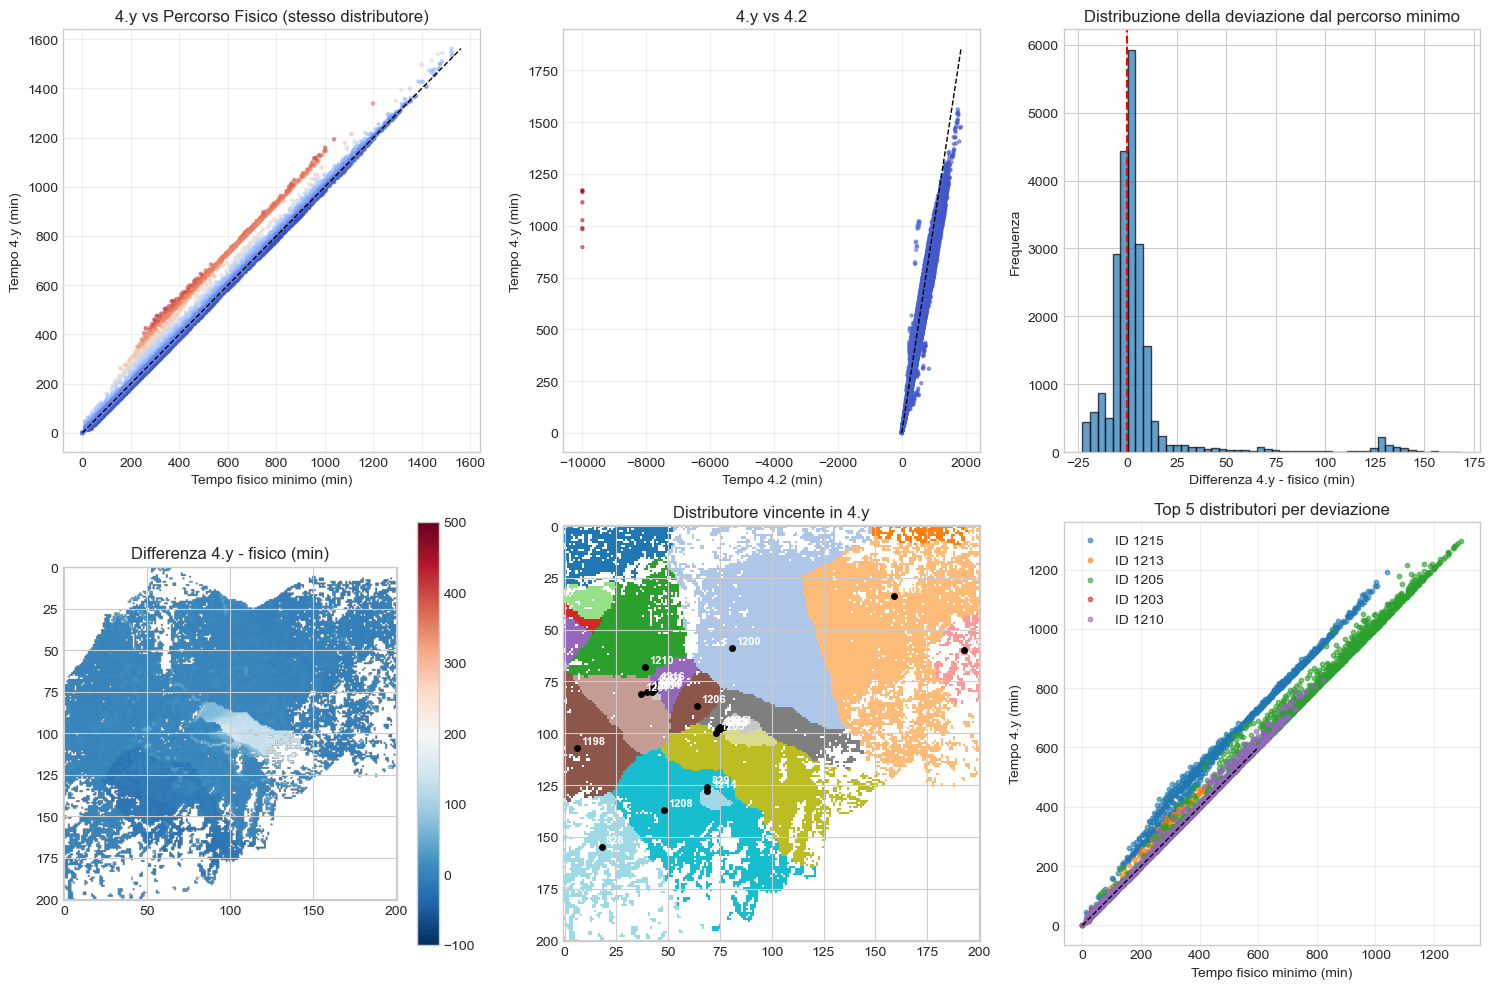


Dati esportati in 'analisi_pixel_intorno.csv'
Riepilogo per distributore esportato in 'riepilogo_per_distributore.csv'

Analisi completata.


In [1]:
"""
Analisi comparativa della competizione spaziale nel modello Huff (4.y vs 4.2)
nell'intorno del pixel (765,762).

Lo script:
- Estrae una finestra di dimensione specificata attorno al pixel target.
- Per ogni pixel valido, recupera i valori dai raster di output 4.y e 4.2.
- Calcola il percorso fisico minimo (Dijkstra isolato) verso il distributore
  assegnato in 4.y, usando la logica di 4.y (8‑vicini, costo destinazione).
- Confronta i tre tempi e genera statistiche, scatter plot e mappe.
"""

import numpy as np
import pandas as pd
import rasterio
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ============================================================
# CONFIGURAZIONE
# ============================================================
CENTER_ROW, CENTER_COL = 765, 762
WINDOW_HALF_SIZE = 100          # Dimensione finestra: (2*HALF+1) x (2*HALF+1)
MIN_VALID_PIXELS_FOR_ANALYSIS = 100  # Minimo pixel validi per analisi

RASTER_4Y = "dataset_big/huff_preferred_distributor_per_pixel_16.tif"
RASTER_42 = "dataset_big/huff_preferred_distributor_per_pixel.tif"
WALK_FRICTION = "dataset_big/friction_walk.tif"
LOOKUP_4Y = "dataset_big/huff_reseller_lookup_16.csv"
LOOKUP_42 = "dataset_big/huff_reseller_lookup.csv"

CELL_SIZE_M = 1000.0
USE_8_NEIGHBORS = True
COST_MODE = 'dest'   # 'dest' per 4.y originale, 'avg' per modificato

# ============================================================
# FUNZIONI DI SUPPORTO
# ============================================================
def build_graph(friction, mask, use_8=True, cost_mode='dest'):
    """
    Costruisce grafo sparse a partire da friction e maschera.
    Restituisce grafo CSR e matrice node_id (stessa forma di friction).
    """
    h, w = friction.shape
    node_id = -np.ones((h, w), dtype=np.int32)
    vr, vc = np.where(mask)
    n_nodes = len(vr)
    if n_nodes == 0:
        raise ValueError("Nessuna cella valida nella maschera")
    node_id[vr, vc] = np.arange(n_nodes, dtype=np.int32)
    
    neighbors = [(-1,0),(1,0),(0,-1),(0,1)]
    if use_8:
        neighbors += [(-1,-1),(-1,1),(1,-1),(1,1)]
    diag_factor = np.sqrt(2.0)
    
    row_idx, col_idx, data = [], [], []
    for r, c in zip(vr, vc):
        n0 = node_id[r, c]
        f0 = friction[r, c]
        for dr, dc in neighbors:
            nr, nc = r+dr, c+dc
            if nr < 0 or nr >= h or nc < 0 or nc >= w:
                continue
            n1 = node_id[nr, nc]
            if n1 < 0:
                continue
            f1 = friction[nr, nc]
            step = CELL_SIZE_M
            if dr != 0 and dc != 0:
                step *= diag_factor
            if cost_mode == 'dest':
                cost = f1 * step
            else:  # 'avg'
                cost = 0.5 * (f0 + f1) * step
            row_idx.append(n0)
            col_idx.append(n1)
            data.append(cost)
    
    graph = csr_matrix((data, (row_idx, col_idx)), shape=(n_nodes, n_nodes))
    return graph, node_id

def shortest_path_to_target(graph, node_id, start_r, start_c, target_node):
    """Dijkstra dal nodo start al target_node. Restituisce distanza e percorso."""
    start_node = node_id[start_r, start_c]
    if start_node < 0 or target_node < 0:
        return np.inf, []
    dist, pred = dijkstra(graph, directed=True, indices=start_node,
                          return_predecessors=True, unweighted=False)
    if not np.isfinite(dist[target_node]):
        return np.inf, []
    path_nodes = [target_node]
    while path_nodes[-1] != start_node:
        p = pred[path_nodes[-1]]
        if p < 0:
            break
        path_nodes.append(p)
    path_nodes.reverse()
    # Converti nodi in coordinate (r,c)
    rows, cols = np.where(node_id >= 0)
    node_to_rc = {node_id[r,c]: (r,c) for r,c in zip(rows, cols)}
    path_rc = [node_to_rc[n] for n in path_nodes]
    return dist[target_node], path_rc

# ============================================================
# 1. CARICAMENTO E PREPARAZIONE DATI
# ============================================================
print("Caricamento raster di output...")
with rasterio.open(RASTER_4Y) as src4y:
    id_4y = src4y.read(3)   # banda 3: reseller ID walk
    time_4y = src4y.read(4) # banda 4: tempo walk (min)
    profile = src4y.profile
    h_full, w_full = id_4y.shape

with rasterio.open(RASTER_42) as src42:
    id_42 = src42.read(3)
    time_42 = src42.read(4)

print("Caricamento friction walk...")
with rasterio.open(WALK_FRICTION) as src_fric:
    # Assumiamo che sia già allineata alla griglia di popolazione
    walk_fric_full = src_fric.read(1).astype(np.float32)
    walk_fric_full = np.where(walk_fric_full > 0, walk_fric_full, np.nan)

print("Caricamento lookup...")
lookup_4y = pd.read_csv(LOOKUP_4Y)
lookup_42 = pd.read_csv(LOOKUP_42)

# ============================================================
# 2. RITAGLIO FINESTRA DI ANALISI
# ============================================================
r_min = max(0, CENTER_ROW - WINDOW_HALF_SIZE)
r_max = min(h_full, CENTER_ROW + WINDOW_HALF_SIZE + 1)
c_min = max(0, CENTER_COL - WINDOW_HALF_SIZE)
c_max = min(w_full, CENTER_COL + WINDOW_HALF_SIZE + 1)

id_4y_win = id_4y[r_min:r_max, c_min:c_max]
time_4y_win = time_4y[r_min:r_max, c_min:c_max]
id_42_win = id_42[r_min:r_max, c_min:c_max]
time_42_win = time_42[r_min:r_max, c_min:c_max]
fric_win = walk_fric_full[r_min:r_max, c_min:c_max]

h_win, w_win = id_4y_win.shape
print(f"Finestra di analisi: righe {r_min}:{r_max}, colonne {c_min}:{c_max} -> dimensione {h_win}x{w_win}")

# Maschera di validità per il grafo (come 4.y: walk finito >0)
mask_win = np.isfinite(fric_win) & (fric_win > 0)

# ============================================================
# 3. COSTRUZIONE GRAFO LOCALE (una volta per tutte)
# ============================================================
print("Costruzione grafo locale (8-vicini, costo destinazione)...")
graph_win, node_id_win = build_graph(fric_win, mask_win, use_8=True, cost_mode='dest')

# Mappa dei distributori presenti nella finestra (dal lookup 4.y)
resellers_in_win = {}
for _, row in lookup_4y.iterrows():
    r, c = int(row['row']), int(row['col'])
    if r_min <= r < r_max and c_min <= c < c_max:
        # Coordinate locali
        r_loc, c_loc = r - r_min, c - c_min
        if mask_win[r_loc, c_loc]:
            node = node_id_win[r_loc, c_loc]
            resellers_in_win[int(row['reseller_id'])] = (r_loc, c_loc, node, row['attractiveness'])

print(f"Distributori nella finestra: {len(resellers_in_win)}")

# ============================================================
# 4. ITERAZIONE SU TUTTI I PIXEL VALIDI DELLA FINESTRA
# ============================================================
valid_pixels = np.where(mask_win)
n_valid = len(valid_pixels[0])
print(f"Pixel validi nella finestra: {n_valid}")

# Preparazione array per i risultati
results = {
    'pixel_row_global': [],
    'pixel_col_global': [],
    'reseller_4y': [],
    'time_4y': [],
    'reseller_42': [],
    'time_42': [],
    'phys_time_to_reseller_4y': [],
    'phys_path_length': [],
    'time_diff_4y_vs_phys': [],
    'time_diff_4y_vs_42': [],
}

# Dizionario per statistiche per distributore
reseller_stats = defaultdict(lambda: {'count':0, 'sum_time_4y':0, 'sum_time_phys':0, 'sum_time_42':0})

# Contatore per progresso
progress_step = max(1, n_valid // 20)

for idx in range(n_valid):
    r_loc = valid_pixels[0][idx]
    c_loc = valid_pixels[1][idx]
    
    r_glob = r_loc + r_min
    c_glob = c_loc + c_min
    
    # Valori da raster
    rid_4y = id_4y_win[r_loc, c_loc]
    t_4y = time_4y_win[r_loc, c_loc]
    rid_42 = id_42_win[r_loc, c_loc]
    t_42 = time_42_win[r_loc, c_loc]
    
    # Se il pixel non è assegnato in 4.y, salta
    if rid_4y <= 0 or np.isnan(t_4y) or t_4y >= 1e5:
        continue
    
    # Trova il nodo target (distributore assegnato in 4.y)
    target_info = resellers_in_win.get(int(rid_4y))
    if target_info is None:
        # Il distributore potrebbe essere fuori dalla finestra: non calcoliamo il percorso fisico
        phys_time = np.nan
        path_len = np.nan
    else:
        _, _, target_node, _ = target_info
        start_node = node_id_win[r_loc, c_loc]
        if start_node >= 0 and target_node >= 0:
            phys_time, path = shortest_path_to_target(graph_win, node_id_win, r_loc, c_loc, target_node)
            path_len = len(path) if path else np.nan
        else:
            phys_time = np.nan
            path_len = np.nan
    
    # Accumula risultati
    results['pixel_row_global'].append(r_glob)
    results['pixel_col_global'].append(c_glob)
    results['reseller_4y'].append(rid_4y)
    results['time_4y'].append(t_4y)
    results['reseller_42'].append(rid_42 if rid_42 > 0 else np.nan)
    results['time_42'].append(t_42 if t_42 < 1e5 else np.nan)
    results['phys_time_to_reseller_4y'].append(phys_time)
    results['phys_path_length'].append(path_len)
    
    diff_phys = t_4y - phys_time if np.isfinite(phys_time) else np.nan
    diff_42 = t_4y - t_42 if np.isfinite(t_42) else np.nan
    results['time_diff_4y_vs_phys'].append(diff_phys)
    results['time_diff_4y_vs_42'].append(diff_42)
    
    # Aggiorna statistiche per distributore
    if np.isfinite(phys_time):
        reseller_stats[int(rid_4y)]['count'] += 1
        reseller_stats[int(rid_4y)]['sum_time_4y'] += t_4y
        reseller_stats[int(rid_4y)]['sum_time_phys'] += phys_time
    if np.isfinite(t_42):
        reseller_stats[int(rid_4y)]['sum_time_42'] += t_42
    
    if (idx+1) % progress_step == 0:
        print(f"  Processati {idx+1}/{n_valid} pixel")

print("Analisi pixel completata.")

# Converti results in DataFrame
df = pd.DataFrame(results)
print(f"Pixel analizzati (con assegnazione 4.y valida): {len(df)}")

# ============================================================
# 5. STATISTICHE RIASSUNTIVE
# ============================================================
print("\n" + "="*60)
print("STATISTICHE GENERALI")
print("="*60)

# Filtra righe con valori validi per ciascun confronto
valid_phys = df['phys_time_to_reseller_4y'].notna()
valid_42 = df['time_42'].notna()

print(f"Pixel con percorso fisico calcolabile: {valid_phys.sum()} ({100*valid_phys.mean():.1f}%)")
print(f"Pixel con assegnazione 4.2 valida: {valid_42.sum()} ({100*valid_42.mean():.1f}%)")

# Differenze medie
if valid_phys.any():
    diff_phys_mean = df.loc[valid_phys, 'time_diff_4y_vs_phys'].mean()
    diff_phys_median = df.loc[valid_phys, 'time_diff_4y_vs_phys'].median()
    print(f"\nDifferenza tempo 4.y - fisico: media={diff_phys_mean:.2f} min, mediana={diff_phys_median:.2f} min")

if valid_42.any():
    diff_42_mean = df.loc[valid_42, 'time_diff_4y_vs_42'].mean()
    diff_42_median = df.loc[valid_42, 'time_diff_4y_vs_42'].median()
    print(f"Differenza tempo 4.y - 4.2: media={diff_42_mean:.2f} min, mediana={diff_42_median:.2f} min")

# Distributori che causano maggiore deviazione
print("\nTop 10 distributori per deviazione media (4.y - fisico):")
reseller_deviation = []
for rid, stats in reseller_stats.items():
    if stats['count'] >= 5:
        avg_4y = stats['sum_time_4y'] / stats['count']
        avg_phys = stats['sum_time_phys'] / stats['count']
        avg_diff = avg_4y - avg_phys
        reseller_deviation.append((rid, stats['count'], avg_diff, avg_4y, avg_phys))
reseller_deviation.sort(key=lambda x: x[2], reverse=True)
for rid, cnt, diff, avg4, avgp in reseller_deviation[:10]:
    print(f"  ID {int(rid):4d}: n={cnt:5d}, diff_media={diff:7.2f} min  (4.y={avg4:.1f}, fisico={avgp:.1f})")

# ============================================================
# 6. VISUALIZZAZIONI
# ============================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Scatter plot: tempo 4.y vs tempo fisico
ax = axes[0,0]
mask = valid_phys
ax.scatter(df.loc[mask, 'phys_time_to_reseller_4y'], df.loc[mask, 'time_4y'],
           c=df.loc[mask, 'time_diff_4y_vs_phys'], cmap='coolwarm', alpha=0.5, s=5)
ax.plot([0, max(df.loc[mask, 'phys_time_to_reseller_4y'].max(), df.loc[mask, 'time_4y'].max())],
        [0, max(df.loc[mask, 'phys_time_to_reseller_4y'].max(), df.loc[mask, 'time_4y'].max())], 'k--', lw=1)
ax.set_xlabel('Tempo fisico minimo (min)')
ax.set_ylabel('Tempo 4.y (min)')
ax.set_title('4.y vs Percorso Fisico (stesso distributore)')
ax.grid(True, alpha=0.3)

# Scatter plot: tempo 4.y vs tempo 4.2
ax = axes[0,1]
mask = valid_42
ax.scatter(df.loc[mask, 'time_42'], df.loc[mask, 'time_4y'],
           c=df.loc[mask, 'time_diff_4y_vs_42'], cmap='coolwarm', alpha=0.5, s=5)
max_val = max(df.loc[mask, 'time_42'].max(), df.loc[mask, 'time_4y'].max())
ax.plot([0, max_val], [0, max_val], 'k--', lw=1)
ax.set_xlabel('Tempo 4.2 (min)')
ax.set_ylabel('Tempo 4.y (min)')
ax.set_title('4.y vs 4.2')
ax.grid(True, alpha=0.3)

# Istogramma differenza 4.y - fisico
ax = axes[0,2]
diff_phys = df.loc[valid_phys, 'time_diff_4y_vs_phys']
ax.hist(diff_phys, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('Differenza 4.y - fisico (min)')
ax.set_ylabel('Frequenza')
ax.set_title('Distribuzione della deviazione dal percorso minimo')

# Mappa di calore della differenza 4.y - fisico (finestra)
ax = axes[1,0]
diff_map = np.full((h_win, w_win), np.nan)
for _, row in df[valid_phys].iterrows():
    r_loc = int(row['pixel_row_global'] - r_min)
    c_loc = int(row['pixel_col_global'] - c_min)
    diff_map[r_loc, c_loc] = row['time_diff_4y_vs_phys']
im = ax.imshow(diff_map, cmap='RdBu_r', origin='upper', vmin=-100, vmax=500)
ax.set_title('Differenza 4.y - fisico (min)')
plt.colorbar(im, ax=ax)

# Mappa dei distributori vincenti in 4.y (codifica a colori)
ax = axes[1,1]
winner_map = np.full((h_win, w_win), np.nan)
unique_resellers = df['reseller_4y'].unique()
color_dict = {rid: i for i, rid in enumerate(unique_resellers)}
for _, row in df.iterrows():
    r_loc = int(row['pixel_row_global'] - r_min)
    c_loc = int(row['pixel_col_global'] - c_min)
    winner_map[r_loc, c_loc] = color_dict[row['reseller_4y']]
im2 = ax.imshow(winner_map, cmap='tab20', origin='upper', interpolation='nearest')
ax.set_title('Distributore vincente in 4.y')
# Aggiungi marker per i distributori
for rid, (r_loc, c_loc, _, _) in resellers_in_win.items():
    ax.plot(c_loc, r_loc, 'ko', markersize=4)
    ax.text(c_loc+2, r_loc-2, str(int(rid)), color='white', fontsize=8, fontweight='bold')

# Confronto distribuzione tempi per i principali distributori
ax = axes[1,2]
top_resellers = [rid for rid, cnt, _, _, _ in reseller_deviation[:5]]
for rid in top_resellers:
    mask = (df['reseller_4y'] == rid) & valid_phys
    if mask.sum() > 0:
        ax.scatter(df.loc[mask, 'phys_time_to_reseller_4y'], df.loc[mask, 'time_4y'],
                   label=f'ID {int(rid)}', alpha=0.6, s=10)
ax.plot([0, 600], [0, 600], 'k--', lw=1)
ax.set_xlabel('Tempo fisico minimo (min)')
ax.set_ylabel('Tempo 4.y (min)')
ax.set_title('Top 5 distributori per deviazione')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analisi_competizione_huff.png', dpi=150)
plt.show()

# ============================================================
# 7. ESPORTAZIONE DATI
# ============================================================
df.to_csv('analisi_pixel_intorno.csv', index=False)
print("\nDati esportati in 'analisi_pixel_intorno.csv'")

# Riepilogo per distributore
reseller_summary = pd.DataFrame([
    {'reseller_id': rid,
     'count_pixels': stats['count'],
     'avg_time_4y': stats['sum_time_4y']/stats['count'] if stats['count']>0 else np.nan,
     'avg_time_phys': stats['sum_time_phys']/stats['count'] if stats['count']>0 else np.nan,
     'avg_time_42': stats['sum_time_42']/stats['count'] if stats['count']>0 else np.nan,
     'avg_deviation': (stats['sum_time_4y'] - stats['sum_time_phys'])/stats['count'] if stats['count']>0 else np.nan
    } for rid, stats in reseller_stats.items()
])
reseller_summary.to_csv('riepilogo_per_distributore.csv', index=False)
print("Riepilogo per distributore esportato in 'riepilogo_per_distributore.csv'")

print("\nAnalisi completata.")

In [2]:
"""
Stima globale dell'effetto di "blocco" in 4.y (differenza tra tempo 4.y e percorso fisico minimo).
Campiona N pixel casuali tra quelli abitati e calcola la deviazione.
"""

import numpy as np
import pandas as pd
import rasterio
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
import random

# ============================================================
# CONFIGURAZIONE
# ============================================================
N_SAMPLES = 60000                # Numero di pixel da campionare
RANDOM_SEED = 42                # Per riproducibilità

DATA_DIR = "dataset_big"
RASTER_4Y = f"{DATA_DIR}/huff_preferred_distributor_per_pixel_16.tif"
WALK_FRICTION = f"{DATA_DIR}/friction_walk.tif"
LOOKUP_CSV = f"{DATA_DIR}/huff_reseller_lookup_16.csv"

CELL_SIZE_M = 1000.0
USE_8_NEIGHBORS = True
COST_MODE = 'dest'              # 'dest' per 4.y originale

# ============================================================
# FUNZIONI (le stesse dello script precedente, adattate)
# ============================================================
def build_graph(friction, mask, use_8=True, cost_mode='dest'):
    h, w = friction.shape
    node_id = -np.ones((h, w), dtype=np.int32)
    vr, vc = np.where(mask)
    n_nodes = len(vr)
    if n_nodes == 0:
        raise ValueError("Nessuna cella valida")
    node_id[vr, vc] = np.arange(n_nodes, dtype=np.int32)
    
    neighbors = [(-1,0),(1,0),(0,-1),(0,1)]
    if use_8:
        neighbors += [(-1,-1),(-1,1),(1,-1),(1,1)]
    diag_factor = np.sqrt(2.0)
    
    row_idx, col_idx, data = [], [], []
    for r, c in zip(vr, vc):
        n0 = node_id[r, c]
        f0 = friction[r, c]
        for dr, dc in neighbors:
            nr, nc = r+dr, c+dc
            if nr < 0 or nr >= h or nc < 0 or nc >= w:
                continue
            n1 = node_id[nr, nc]
            if n1 < 0:
                continue
            f1 = friction[nr, nc]
            step = CELL_SIZE_M
            if dr != 0 and dc != 0:
                step *= diag_factor
            if cost_mode == 'dest':
                cost = f1 * step
            else:
                cost = 0.5 * (f0 + f1) * step
            row_idx.append(n0)
            col_idx.append(n1)
            data.append(cost)
    
    graph = csr_matrix((data, (row_idx, col_idx)), shape=(n_nodes, n_nodes))
    return graph, node_id

def shortest_path_time(graph, node_id, start_r, start_c, target_node):
    start_node = node_id[start_r, start_c]
    if start_node < 0 or target_node < 0:
        return np.inf
    dist = dijkstra(graph, directed=True, indices=start_node, unweighted=False)
    return dist[target_node]

# ============================================================
# 1. CARICAMENTO DATI
# ============================================================
print("Caricamento raster 4.y e friction...")
with rasterio.open(RASTER_4Y) as src:
    winner_id = src.read(3)   # banda 3: reseller ID walk
    time_4y = src.read(4)     # banda 4: tempo walk (min)
    profile = src.profile
    h, w = winner_id.shape

with rasterio.open(WALK_FRICTION) as src:
    friction = src.read(1).astype(np.float32)
    friction = np.where(friction > 0, friction, np.nan)

# Maschera abitati (pixel con assegnazione valida in 4.y)
valid_pixels_mask = (winner_id > 0) & np.isfinite(time_4y)
rows, cols = np.where(valid_pixels_mask)
n_valid = len(rows)
print(f"Pixel abitati con assegnazione 4.y: {n_valid:,}")

# Carica lookup reseller
lookup = pd.read_csv(LOOKUP_CSV)
reseller_coords = {}
for _, row in lookup.iterrows():
    reseller_coords[int(row['reseller_id'])] = (int(row['row']), int(row['col']))

# ============================================================
# 2. CAMPIONAMENTO CASUALE
# ============================================================
random.seed(RANDOM_SEED)
sample_indices = random.sample(range(n_valid), min(N_SAMPLES, n_valid))
sample_rows = rows[sample_indices]
sample_cols = cols[sample_indices]
print(f"Campionati {len(sample_rows)} pixel.")

# ============================================================
# 3. COSTRUZIONE GRAFO GLOBALE (una tantum)
# ============================================================
print("Costruzione grafo globale (8-vicini, costo destinazione)...")
mask_global = np.isfinite(friction) & (friction > 0)
graph, node_id = build_graph(friction, mask_global, use_8=USE_8_NEIGHBORS, cost_mode=COST_MODE)

# ============================================================
# 4. CALCOLO DEVIAZIONI PER I PIXEL CAMPIONATI
# ============================================================
results = []
for i, (r, c) in enumerate(zip(sample_rows, sample_cols)):
    if (i+1) % 500 == 0:
        print(f"  Processati {i+1}/{len(sample_rows)} pixel")
    
    rid = int(winner_id[r, c])
    t_4y = time_4y[r, c]
    
    # Posizione del reseller assegnato
    if rid not in reseller_coords:
        continue
    res_r, res_c = reseller_coords[rid]
    
    # Nodo di partenza (pixel) e arrivo (reseller)
    start_node = node_id[r, c]
    target_node = node_id[res_r, res_c]
    
    if start_node < 0 or target_node < 0:
        continue
    
    t_phys = shortest_path_time(graph, node_id, r, c, target_node)
    
    if np.isfinite(t_phys):
        deviation = t_4y - t_phys
        results.append({
            'row': r,
            'col': c,
            'reseller_id': rid,
            'time_4y': t_4y,
            'time_phys': t_phys,
            'deviation': deviation
        })

# ============================================================
# 5. STATISTICHE
# ============================================================
df = pd.DataFrame(results)
print(f"\nPixel con percorso fisico calcolabile: {len(df)}")

if len(df) > 0:
    print("\n=== STATISTICHE GLOBALI (CAMPIONE) ===")
    print(f"Deviazione media:   {df['deviation'].mean():.2f} min")
    print(f"Deviazione mediana: {df['deviation'].median():.2f} min")
    print(f"Deviazione std:     {df['deviation'].std():.2f} min")
    print(f"Min / Max:          {df['deviation'].min():.2f} / {df['deviation'].max():.2f} min")
    
    # Percentili
    for p in [25, 50, 75, 90, 95, 99]:
        val = np.percentile(df['deviation'], p)
        print(f"  {p}° percentile: {val:.2f} min")
    
    # Frazione di pixel con deviazione > soglia
    for threshold in [1, 5, 10, 30, 60]:
        frac = (df['deviation'] > threshold).mean() * 100
        print(f"Pixel con deviazione > {threshold:2d} min: {frac:.1f}%")
    
    # Salva CSV
    df.to_csv("deviazione_globale_campione.csv", index=False)
    print("\nRisultati salvati in 'deviazione_globale_campione.csv'")

Caricamento raster 4.y e friction...
Pixel abitati con assegnazione 4.y: 563,851
Campionati 60000 pixel.
Costruzione grafo globale (8-vicini, costo destinazione)...
  Processati 500/60000 pixel
  Processati 1000/60000 pixel
  Processati 1500/60000 pixel
  Processati 2000/60000 pixel
  Processati 2500/60000 pixel
  Processati 3000/60000 pixel
  Processati 3500/60000 pixel
  Processati 4000/60000 pixel
  Processati 4500/60000 pixel
  Processati 5000/60000 pixel
  Processati 5500/60000 pixel
  Processati 6000/60000 pixel
  Processati 6500/60000 pixel
  Processati 7000/60000 pixel
  Processati 7500/60000 pixel
  Processati 8000/60000 pixel
  Processati 8500/60000 pixel
  Processati 9000/60000 pixel
  Processati 9500/60000 pixel
  Processati 10000/60000 pixel
  Processati 10500/60000 pixel
  Processati 11000/60000 pixel
  Processati 11500/60000 pixel
  Processati 12000/60000 pixel
  Processati 12500/60000 pixel
  Processati 13000/60000 pixel
  Processati 13500/60000 pixel
  Processati 14000